C:\Users\Tannis\AppData\Local\Temp\ipykernel_3476\762853494.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


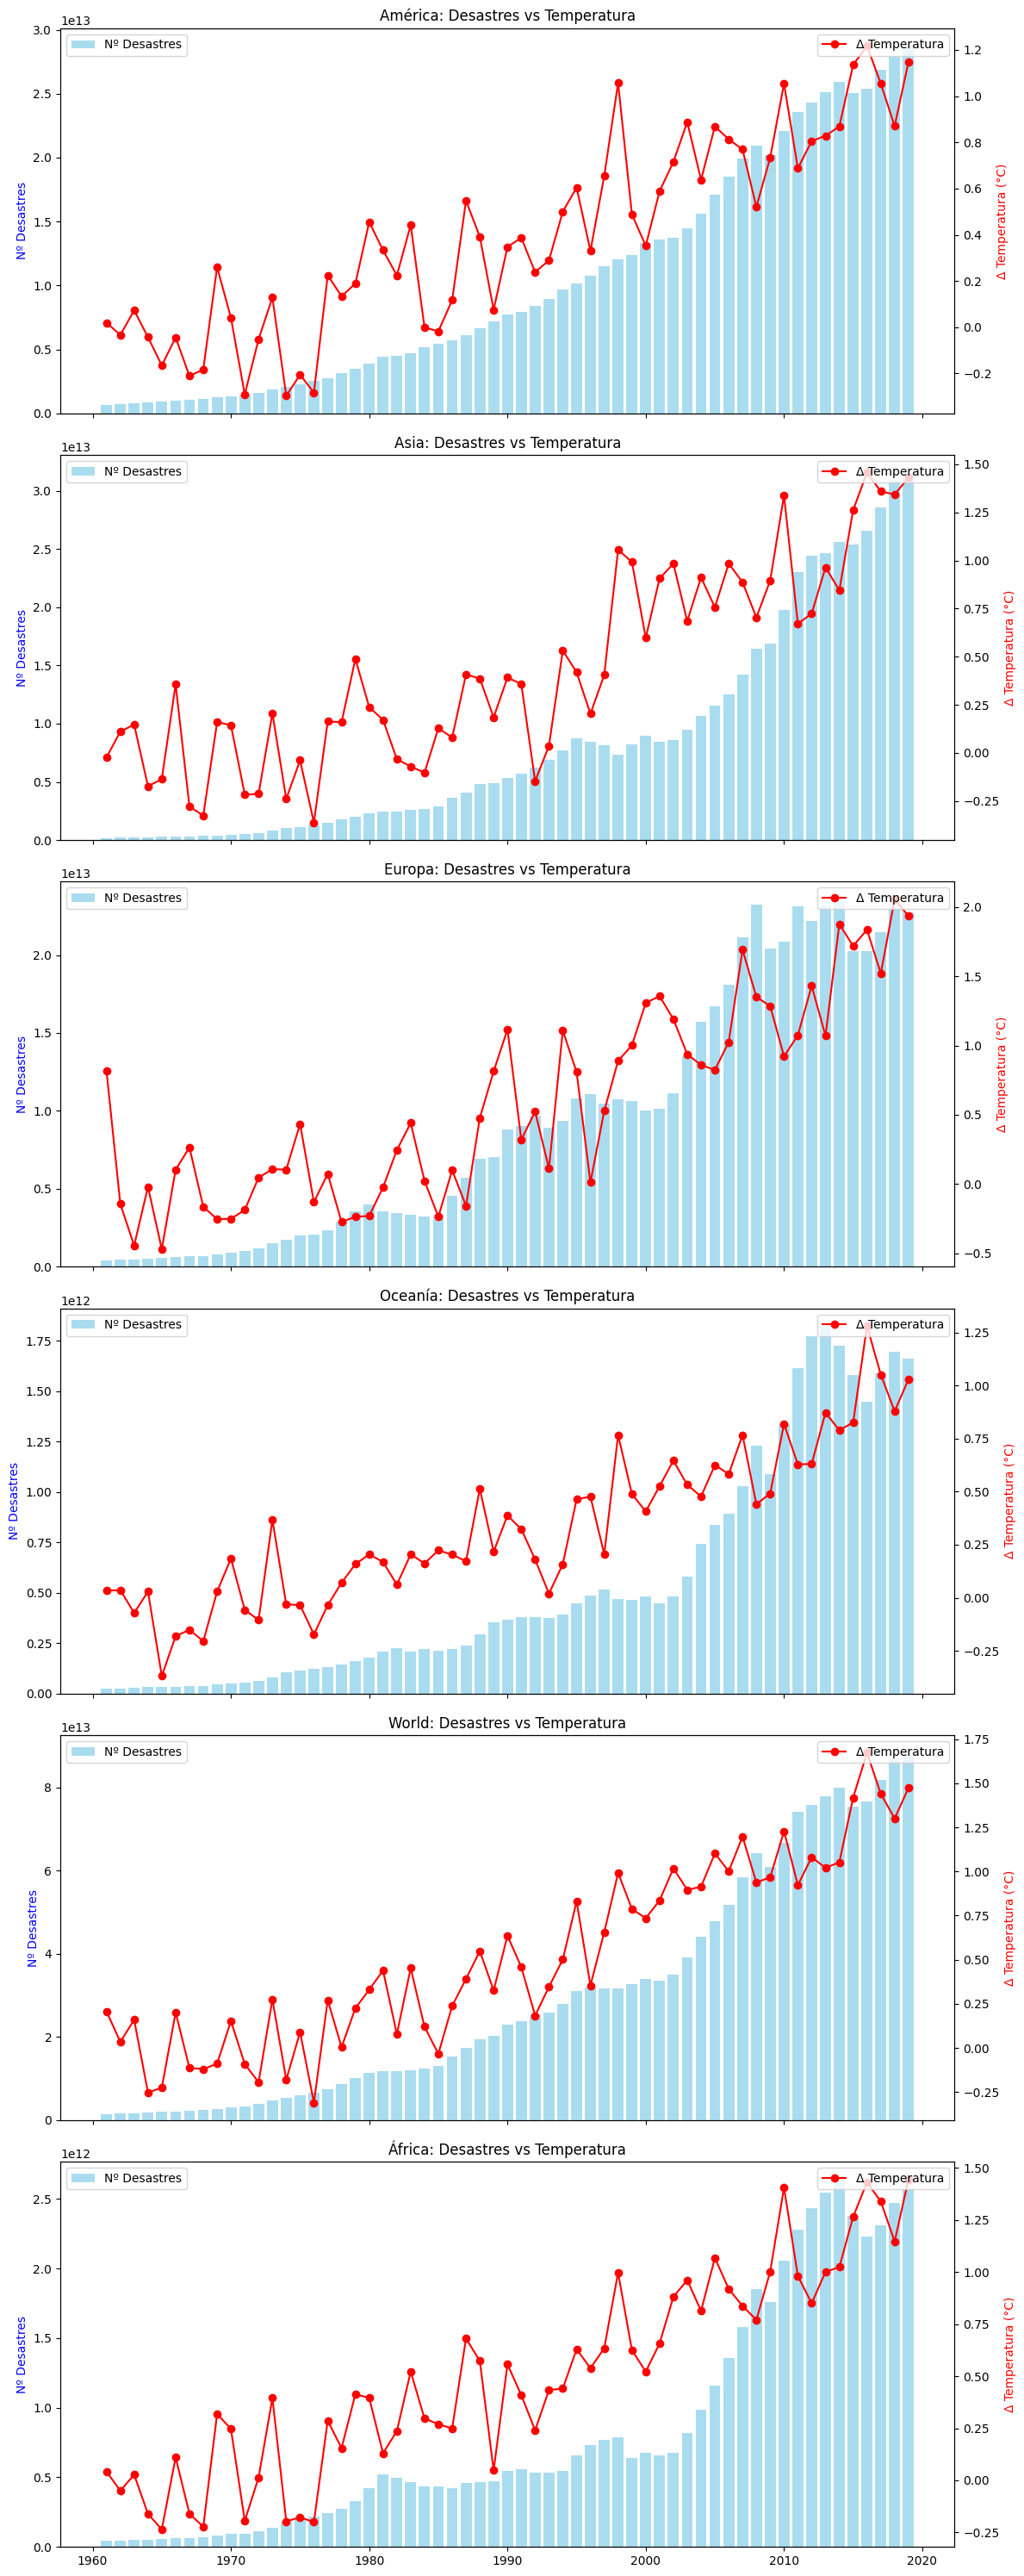

In [4]:
import pandas as pd
import pymysql
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os

# ======== Conexión =========
load_dotenv()
conn = pymysql.connect(
    host=os.getenv("DB_HOST"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    database=os.getenv("DB_NAME")
)

# ======== Query =========
query = """
SELECT 
    h.anio,
    h.valor,
    h.indicador_id,
    p.continente_id,
    c.nombre AS continente
FROM hechos h
JOIN paises p ON h.pais_id = p.codigo
JOIN continentes c ON p.continente_id = c.id
"""
df = pd.read_sql(query, conn)

# ======== Procesar =========
# Desastres = todos los indicadores con categoria_id=4,
# pero si no tienes la relación, asumimos que son id >= 5 (ajusta según tu tabla indicadores)
# Temperatura = indicador_id = 1

df_temp = df[df["indicador_id"] == 1].groupby(["anio", "continente"]).agg({"valor": "mean"}).reset_index()
df_temp.rename(columns={"valor": "temp_var"}, inplace=True)

df_desastres = df[df["indicador_id"] != 1].groupby(["anio", "continente"]).agg({"valor": "sum"}).reset_index()
df_desastres.rename(columns={"valor": "n_desastres"}, inplace=True)

df_merge = pd.merge(df_desastres, df_temp, on=["anio", "continente"], how="inner")

# ======== Plot =========
continentes = df_merge["continente"].unique()
n = len(continentes)

fig, axes = plt.subplots(n, 1, figsize=(12, 5*n), sharex=True)

if n == 1:
    axes = [axes]

for ax, cont in zip(axes, continentes):
    sub = df_merge[df_merge["continente"] == cont].sort_values("anio")

    ax.bar(sub["anio"], sub["n_desastres"], color="skyblue", alpha=0.7, label="Nº Desastres")
    ax.set_ylabel("Nº Desastres", color="blue")
    
    ax2 = ax.twinx()
    ax2.plot(sub["anio"], sub["temp_var"], color="red", marker="o", label="Δ Temperatura")
    ax2.set_ylabel("Δ Temperatura (°C)", color="red")

    ax.set_title(f"{cont}: Desastres vs Temperatura")
    ax.legend(loc="upper left")
    ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()


C:\Users\Tannis\AppData\Local\Temp\ipykernel_3476\1030867622.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


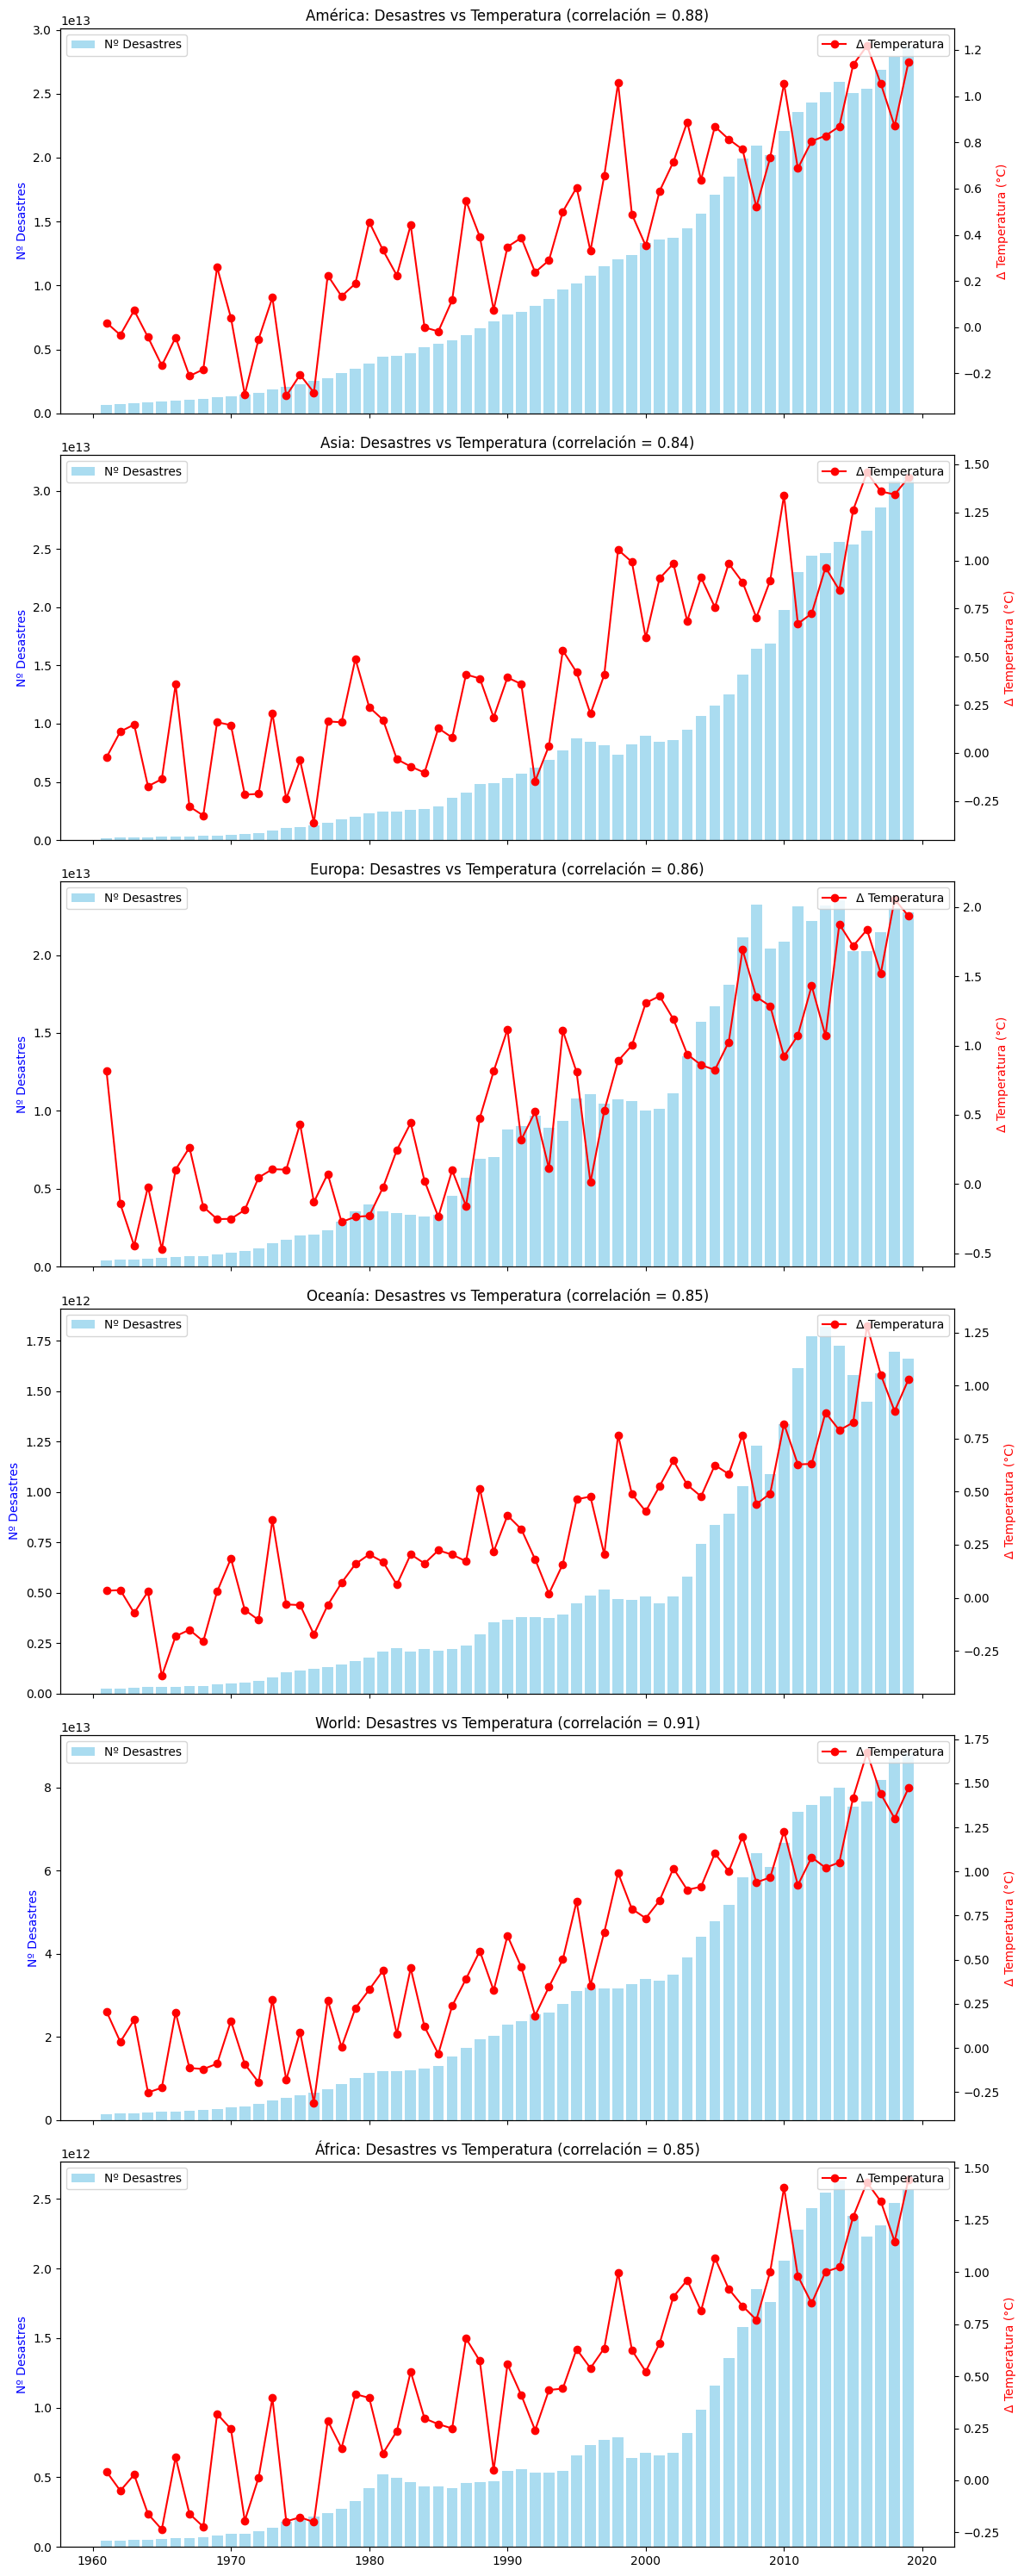

In [5]:
import pandas as pd
import pymysql
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os

# ======== Conexión =========
load_dotenv()
conn = pymysql.connect(
    host=os.getenv("DB_HOST"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    database=os.getenv("DB_NAME")
)

# ======== Query =========
query = """
SELECT 
    h.anio,
    h.valor,
    h.indicador_id,
    p.continente_id,
    c.nombre AS continente
FROM hechos h
JOIN paises p ON h.pais_id = p.codigo
JOIN continentes c ON p.continente_id = c.id
"""
df = pd.read_sql(query, conn)

# ======== Procesar =========
df_temp = df[df["indicador_id"] == 1].groupby(["anio", "continente"]).agg({"valor": "mean"}).reset_index()
df_temp.rename(columns={"valor": "temp_var"}, inplace=True)

df_desastres = df[df["indicador_id"] != 1].groupby(["anio", "continente"]).agg({"valor": "sum"}).reset_index()
df_desastres.rename(columns={"valor": "n_desastres"}, inplace=True)

df_merge = pd.merge(df_desastres, df_temp, on=["anio", "continente"], how="inner")

# ======== Plot =========
continentes = df_merge["continente"].unique()
n = len(continentes)

fig, axes = plt.subplots(n, 1, figsize=(12, 5*n), sharex=True)

if n == 1:
    axes = [axes]

for ax, cont in zip(axes, continentes):
    sub = df_merge[df_merge["continente"] == cont].sort_values("anio")

    # --- Calcular correlación
    if len(sub) > 1:
        corr = sub["n_desastres"].corr(sub["temp_var"])
    else:
        corr = float("nan")

    # --- Graficar
    ax.bar(sub["anio"], sub["n_desastres"], color="skyblue", alpha=0.7, label="Nº Desastres")
    ax.set_ylabel("Nº Desastres", color="blue")
    
    ax2 = ax.twinx()
    ax2.plot(sub["anio"], sub["temp_var"], color="red", marker="o", label="Δ Temperatura")
    ax2.set_ylabel("Δ Temperatura (°C)", color="red")

    ax.set_title(f"{cont}: Desastres vs Temperatura (correlación = {corr:.2f})")
    ax.legend(loc="upper left")
    ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()



C:\Users\Tannis\AppData\Local\Temp\ipykernel_3476\3240612993.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_disasters = pd.read_sql(query, conn)


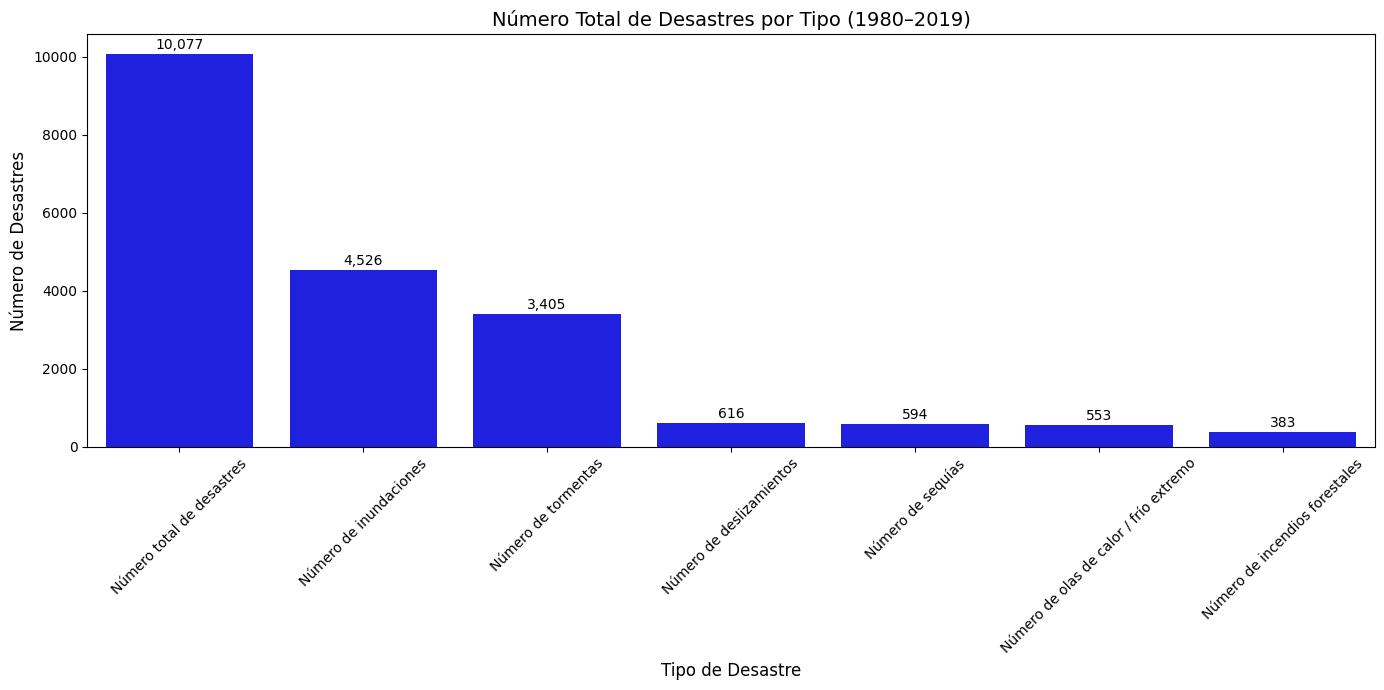

In [34]:
import pandas as pd
import pymysql
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv

# ======================
# Conexión
# ======================
load_dotenv()
conn = pymysql.connect(
    host=os.getenv("DB_HOST"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    database=os.getenv("DB_NAME")
)

query = """
SELECT 
    h.anio,
    i.descripcion AS tipo_desastre,
    h.valor AS frecuencia
FROM hechos h
JOIN indicadores i ON h.indicador_id = i.id
WHERE h.indicador_id IN (10, 5, 6, 7, 8, 9,11)
  AND h.anio BETWEEN 1980 AND 2019;
"""
df_disasters = pd.read_sql(query, conn)

# =====================
# 2. Agrupar por tipo de desastre
# =====================
disasters_by_type = (
    df_disasters.groupby("tipo_desastre")["frecuencia"]
    .sum()
    .sort_values(ascending=False)
)

# =====================
# 3. Graficar
# =====================
plt.figure(figsize=(14, 7))
sns.barplot(x=disasters_by_type.index, y=disasters_by_type.values, color="blue")

# Títulos y ejes
plt.title("Número Total de Desastres por Tipo (1980–2019)", fontsize=14)
plt.xlabel("Tipo de Desastre", fontsize=12)
plt.ylabel("Número de Desastres", fontsize=12)
plt.xticks(rotation=45)

# Etiquetas encima de cada barra
for i, v in enumerate(disasters_by_type.values):
    plt.text(i, v + 50, f"{v:,.0f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()


C:\Users\Tannis\AppData\Local\Temp\ipykernel_3476\3400113668.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_disasters = pd.read_sql(query, conn)


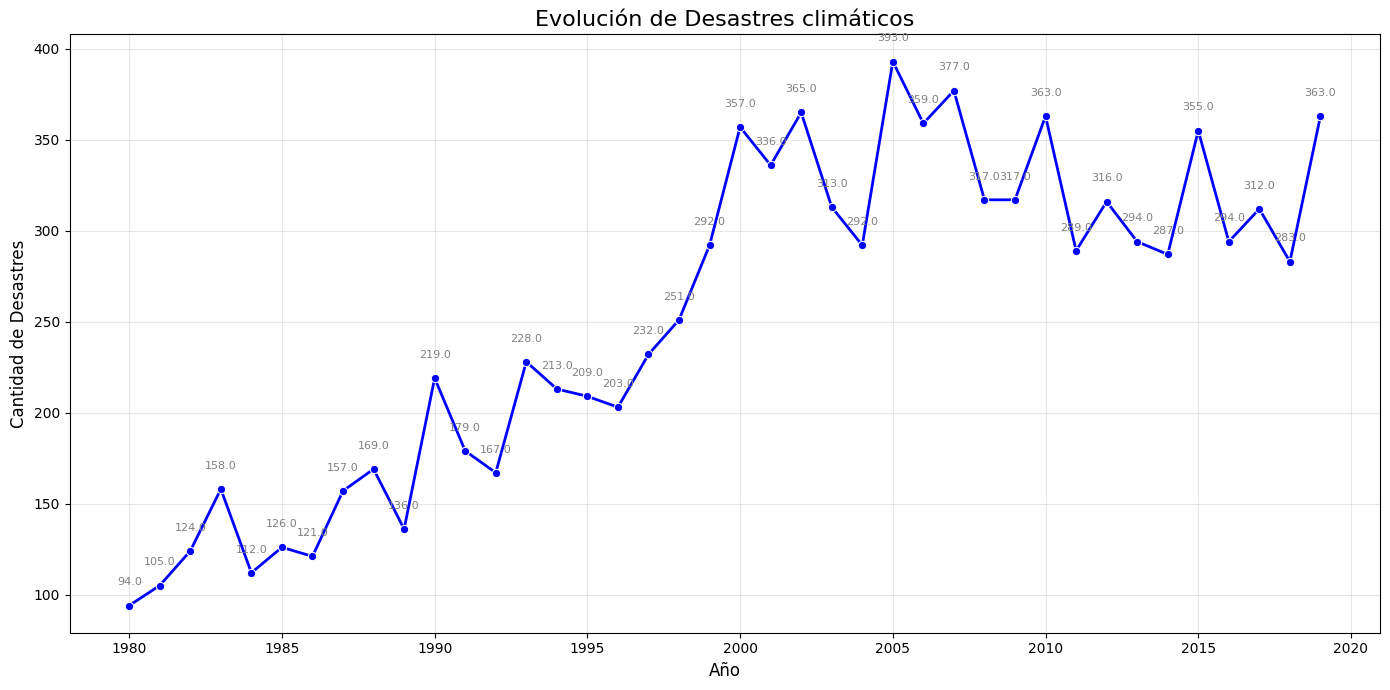

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pymysql
import os
from dotenv import load_dotenv

# Conexión a la base
load_dotenv()
conn = pymysql.connect(
    host=os.getenv("DB_HOST"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    database=os.getenv("DB_NAME")
)

# Query para traer solo los desastres (indicadores 4–9)
query = """
SELECT 
    h.anio,
    h.valor AS frecuencia
FROM hechos h
WHERE h.indicador_id IN (10)
  AND h.anio BETWEEN 1980 AND 2019;
"""
df_disasters = pd.read_sql(query, conn)

# Agrupar por año
disasters_by_year = df_disasters.groupby("anio")["frecuencia"].sum().reset_index()

# Graficar
plt.figure(figsize=(14, 7))
sns.lineplot(data=disasters_by_year, x="anio", y="frecuencia", 
             marker="o", color="blue", linewidth=2)

# Etiquetas en los puntos
for i, row in disasters_by_year.iterrows():
    plt.text(row["anio"], row["frecuencia"] + 10, f"{row['frecuencia']:.1f}",
             ha="center", va="bottom", fontsize=8, color="gray")

# Configuración general
plt.title("Evolución de Desastres climáticos", fontsize=16)
plt.xlabel("Año", fontsize=12)
plt.ylabel("Cantidad de Desastres", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


C:\Users\Tannis\AppData\Local\Temp\ipykernel_3476\2553864629.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_evolucion = pd.read_sql(query, conn)


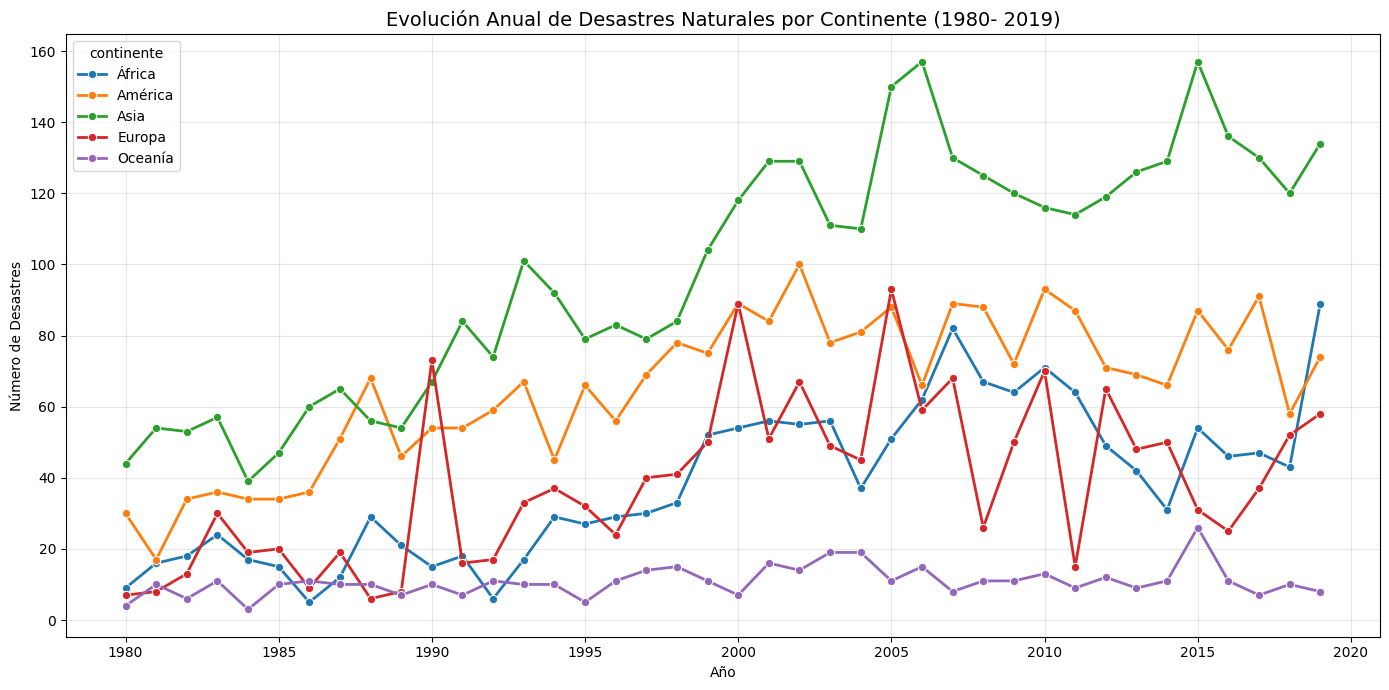

In [35]:
# Query con evolución anual por continente hasta 2019
query = """
SELECT 
    h.anio,
    c.nombre AS continente,
    SUM(h.valor) AS total_desastres
FROM hechos h
JOIN paises p ON h.pais_id = p.codigo
JOIN continentes c ON p.continente_id = c.id
WHERE h.indicador_id IN (10) 
  AND h.anio <= 2019
GROUP BY h.anio, c.nombre
ORDER BY h.anio, c.nombre;
"""

df_evolucion = pd.read_sql(query, conn)

# Gráfico de evolución hasta 2019
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=df_evolucion,
    x="anio",
    y="total_desastres",
    hue="continente",
    marker="o",
    linewidth=2
)

# Títulos y etiquetas
plt.title("Evolución Anual de Desastres Naturales por Continente (1980- 2019)", fontsize=14)
plt.xlabel("Año")
plt.ylabel("Número de Desastres")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


C:\Users\Tannis\AppData\Local\Temp\ipykernel_3476\428505701.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_evolucion = pd.read_sql(query, conn)


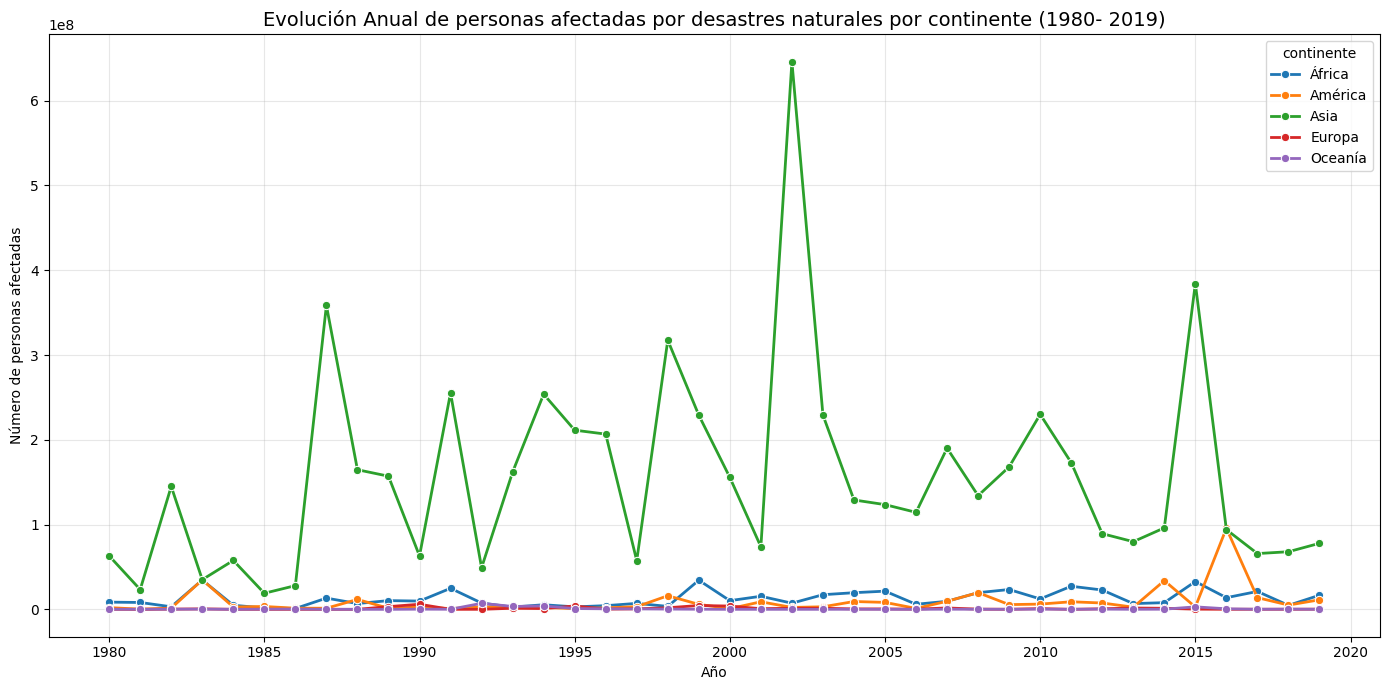

In [40]:
# Query con evolución anual por continente hasta 2019
query = """
SELECT 
    h.anio,
    c.nombre AS continente,
    SUM(h.valor) AS total_desastres
FROM hechos h
JOIN paises p ON h.pais_id = p.codigo
JOIN continentes c ON p.continente_id = c.id
WHERE h.indicador_id IN (17) 
  AND h.anio <= 2019
GROUP BY h.anio, c.nombre
ORDER BY h.anio, c.nombre;
"""

df_evolucion = pd.read_sql(query, conn)

# Gráfico de evolución hasta 2019
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=df_evolucion,
    x="anio",
    y="total_desastres",
    hue="continente",
    marker="o",
    linewidth=2
)

# Títulos y etiquetas
plt.title("Evolución Anual de personas afectadas por desastres naturales por continente (1980- 2019)", fontsize=14)
plt.xlabel("Año")
plt.ylabel("Número de personas afectadas")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\Tannis\AppData\Local\Temp\ipykernel_3476\256304266.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_promedio = pd.read_sql(query, conn)


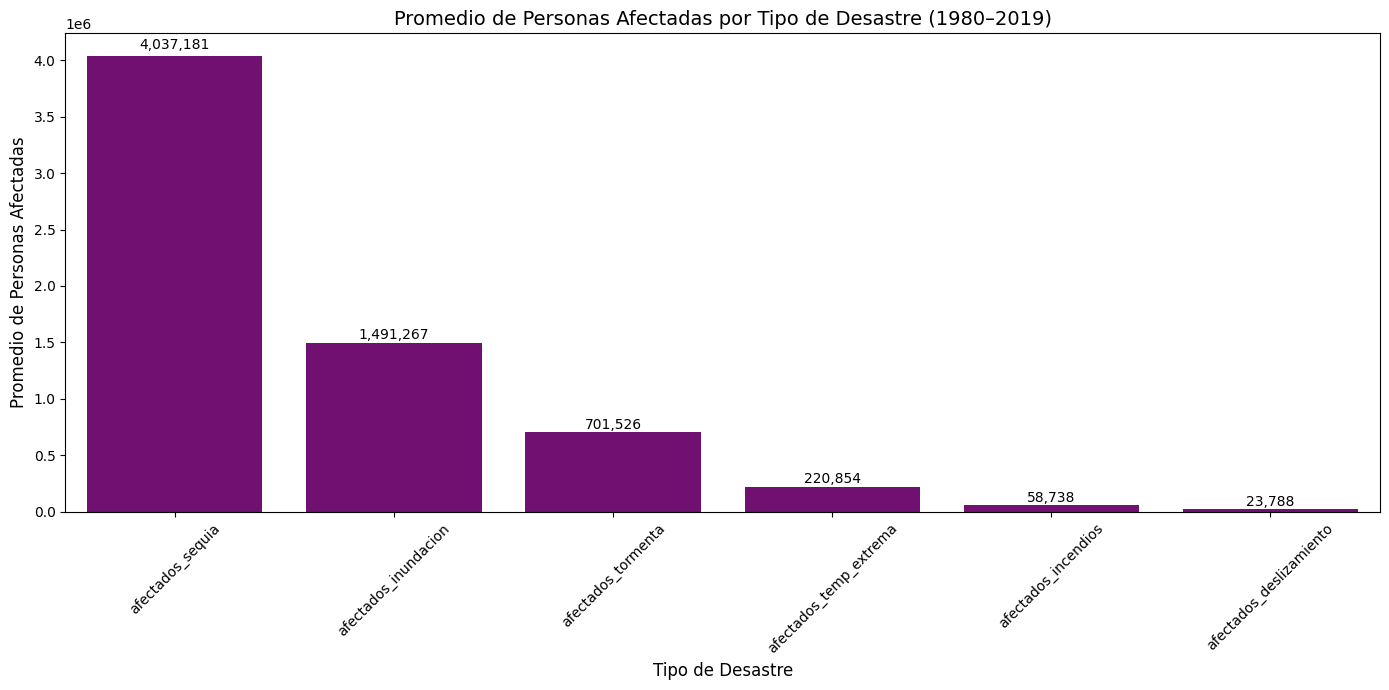

In [49]:
# Query: promedio de personas afectadas por tipo de desastre
query = """
SELECT 
    i.codigo AS tipo_desastre,
    AVG(h.valor) AS promedio_afectados
FROM hechos h
JOIN indicadores i ON h.indicador_id = i.id
WHERE h.indicador_id IN (12, 13, 14, 15, 16, 18)
  AND h.anio BETWEEN 1980 AND 2019
GROUP BY i.id
ORDER BY promedio_afectados DESC;
"""

df_promedio = pd.read_sql(query, conn)

# Graficar
plt.figure(figsize=(14, 7))
sns.barplot(
    data=df_promedio,
    x="tipo_desastre",
    y="promedio_afectados",
    color="purple"
)

plt.title("Promedio de Personas Afectadas por Tipo de Desastre (1980–2019)", fontsize=14)
plt.xlabel("Tipo de Desastre", fontsize=12)
plt.ylabel("Promedio de Personas Afectadas", fontsize=12)
plt.xticks(rotation=45)

for i, v in enumerate(df_promedio["promedio_afectados"]):
    plt.text(i, v + (v * 0.01), f"{v:,.0f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()




C:\Users\Tannis\AppData\Local\Temp\ipykernel_3476\4116120699.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_afectados = pd.read_sql(query, conn)


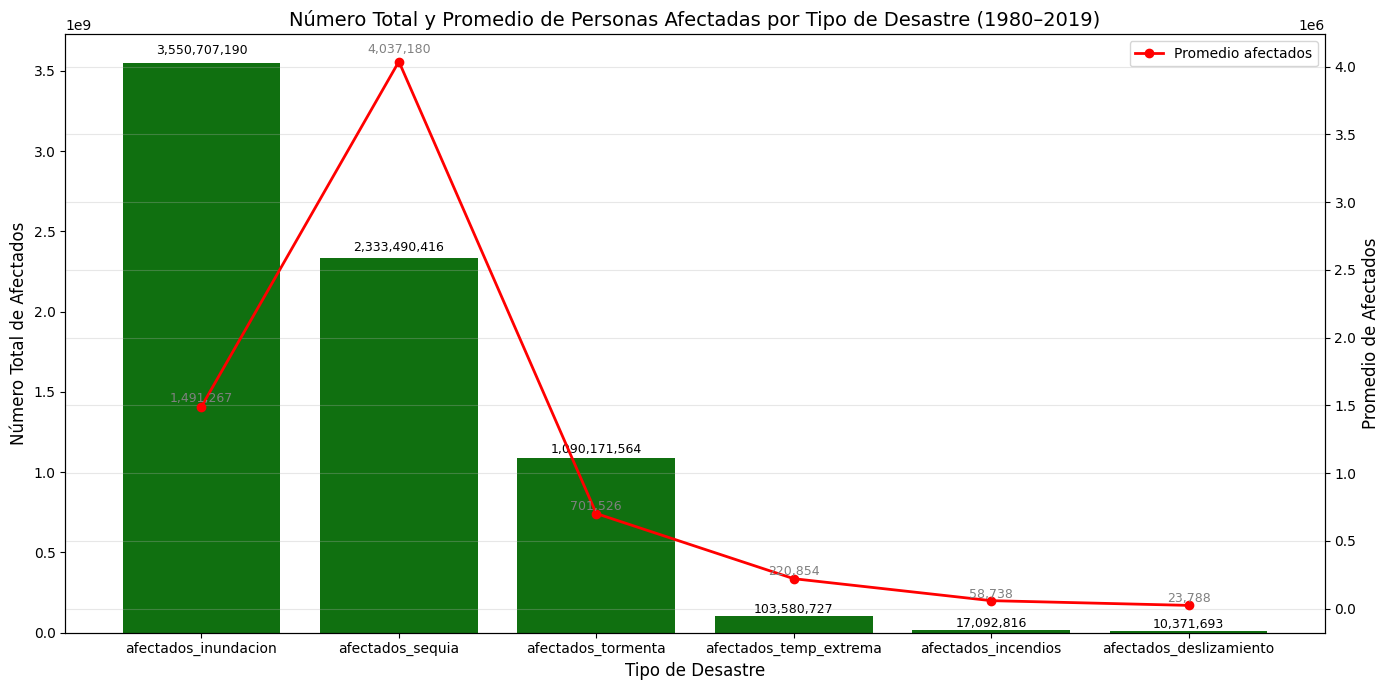

In [53]:
# Query para obtener total y promedio por tipo de desastre
query = """
SELECT 
    i.codigo AS tipo_desastre,
    SUM(h.valor) AS total_afectados,
    AVG(h.valor) AS promedio_afectados
FROM hechos h
JOIN indicadores i ON h.indicador_id = i.id
WHERE h.indicador_id IN (12, 13, 14, 15, 16, 18)
  AND h.anio BETWEEN 1980 AND 2019
GROUP BY i.id
ORDER BY total_afectados DESC;
"""

df_afectados = pd.read_sql(query, conn)

# =====================
# Gráfico combinado
# =====================
fig, ax1 = plt.subplots(figsize=(14, 7))

# Barras para el total
sns.barplot(
    data=df_afectados,
    x="tipo_desastre",
    y="total_afectados",
    color="green",
    ax=ax1
)

# Etiquetas encima de las barras
for i, v in enumerate(df_afectados["total_afectados"]):
    ax1.text(i, v + (v * 0.01), f"{v:,.0f}", ha="center", va="bottom", fontsize=9)

# Eje secundario para el promedio
ax2 = ax1.twinx()
ax2.plot(
    df_afectados["tipo_desastre"],
    df_afectados["promedio_afectados"],
    color="red",
    marker="o",
    linewidth=2,
    label="Promedio afectados"
)

# Etiquetas encima de las linea
for i, v in enumerate(df_afectados["promedio_afectados"]):
    ax2.text(i, v + (v * 0.01), f"{int(v):,}", 
             ha="center", va="bottom", fontsize=9, color="gray")

# Títulos y ejes
ax1.set_title("Número Total y Promedio de Personas Afectadas por Tipo de Desastre (1980–2019)", fontsize=14)
ax1.set_xlabel("Tipo de Desastre", fontsize=12)
ax1.set_ylabel("Número Total de Afectados", fontsize=12, color="black")
ax2.set_ylabel("Promedio de Afectados", fontsize=12, color="black")

# Leyenda
ax2.legend(loc="upper right")

plt.xticks(rotation=45)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
